In [2]:
import numpy as np
import pandas as pd
import statistics
from statsmodels import robust
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from datetime import datetime

In [4]:
def asset_return(ticker_list):
    """Download max historical daily returns for each ticker and return a combined DataFrame."""
    ticker_return = []
    for ticker in ticker_list.keys():
        t = yf.Ticker(ticker)
        ticker_df = t.history(period='max')
        ticker_df['Return'] = ticker_df['Close'].pct_change()
        ticker_df.index = pd.Index(ticker_df.index.values.astype('M8[D]'))  # yyyy-mm-dd
        ticker_return.append(ticker_df['Return'])

    ticker_return = pd.concat(ticker_return, axis=1).ffill().dropna(how='any')
    ticker_return.columns = list(ticker_list.values())
    return ticker_return


def asset_return_des_stats(ticker_series):
    """Compute descriptive statistics for a single asset return Series."""
    ticker_mean_mad   = (ticker_series - ticker_series.mean()).abs().mean()
    ticker_median_mad = robust.mad(ticker_series, c=1)
    ticker_skewness   = ticker_series.skew()
    ticker_kurtosis   = stats.kurtosis(ticker_series, fisher=False)  # Pearson kurtosis
    ticker_describe   = ticker_series.describe()

    ticker_misc = pd.DataFrame(
        [ticker_mean_mad, ticker_median_mad, ticker_skewness, ticker_kurtosis],
        index=['mean_mad', 'median_mad', 'skewness', 'kurtosis'],
        columns=[ticker_series.name]
    )
    ticker_des_stats = pd.concat([ticker_describe.to_frame(), ticker_misc], axis=0)[ticker_series.name]
    return ticker_des_stats


def asset_return_histogram(ticker_df):
    """Plot one histogram subplot per asset."""
    fig, axes = plt.subplots(1, ticker_df.shape[1], figsize=(15, 3))
    for ax, col in zip(axes, ticker_df.columns):
        sns.histplot(data=ticker_df[col], ax=ax)
        ax.set_title('Return histogram of ' + col, fontsize=8)
        ax.set(ylabel='', xlabel='')
    plt.tight_layout()
    return fig


def asset_return_plots(ticker_df):
    """Plot boxplot, stripplot, violinplot, and overlaid boxplot+stripplot."""
    box_properties = {
        'boxprops':     {'facecolor': 'none', 'edgecolor': 'black'},
        'medianprops':  {'color': 'black'},
        'whiskerprops': {'color': 'black'},
        'capprops':     {'color': 'black'}
    }

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    # Subplot 1: Boxplot
    sns.boxplot(data=ticker_df, **box_properties, ax=axes[0])
    axes[0].set_title('Return Boxplot')
    axes[0].set(ylim=(-0.1, 0.1))
    axes[0].xaxis.set_tick_params(labelsize=7)

    # Subplot 2: Stripplot
    sns.stripplot(data=ticker_df, ax=axes[1])
    axes[1].set_title('Return Stripplot')
    axes[1].set(ylim=(-0.1, 0.1))
    axes[1].xaxis.set_tick_params(labelsize=7)

    # Subplot 3: Violinplot
    sns.violinplot(data=ticker_df, ax=axes[2])
    axes[2].set_title('Return Violinplot')
    axes[2].set(ylim=(-0.1, 0.1))
    axes[2].xaxis.set_tick_params(labelsize=7)

    # Subplot 4: Overlaid boxplot + stripplot
    sns.boxplot(data=ticker_df,  **box_properties, ax=axes[3])
    sns.stripplot(data=ticker_df, ax=axes[3])
    axes[3].set_title('Return Boxplot + Stripplot')
    axes[3].set(ylim=(-0.1, 0.1))
    axes[3].xaxis.set_tick_params(labelsize=7)

    sns.despine()
    plt.tight_layout()
    return fig


def asset_return_regplots(ticker_df):
    """Plot full NxN grid of bivariate regplots for all asset pairs."""
    n = len(ticker_df.columns)
    fig, axes = plt.subplots(n, n, figsize=(15, 15))
    plt.subplots_adjust(hspace=0.5, wspace=0.5)

    for i in range(n):
        for j in range(n):
            sns.regplot(
                data=ticker_df,
                x=ticker_df.iloc[:, i],
                y=ticker_df.iloc[:, j],
                scatter_kws={'color': 'black', 's': 2},
                line_kws={'color': 'red', 'lw': 1},
                ax=axes[i, j]
            )
            axes[i, j].set_title(
                ticker_df.columns[j] + ' vs. ' + ticker_df.columns[i],
                fontsize=7
            )
            axes[i, j].set(xlim=(-0.25, 0.25), ylim=(-0.25, 0.25))
            axes[i, j].xaxis.set_tick_params(labelsize=6)
            axes[i, j].yaxis.set_tick_params(labelsize=6)

    sns.despine()
    return fig

In [5]:
# List of 5 assets
ticker_list = {
    'MSFT':   'Microsoft',
    'TSLA':    'Tesla',
    'AMZN':    'Amazon',
    'KO':    'CocaCola',
    'UNH': 'United Health'
}

# DataFrame of daily asset returns
asset_return_df = asset_return(ticker_list)

# Descriptive statistics (one column per asset)
asset_des_stats = asset_return_df.apply(asset_return_des_stats, axis=0)

# Covariance and correlation matrices
asset_return_df_cov    = asset_return_df.cov()
asset_return_df_corr_p = asset_return_df.corr(method='pearson')
asset_return_df_corr_s = asset_return_df.corr(method='spearman')

In [6]:
# Asset return DataFrame
asset_return_df

,Microsoft,Tesla,Amazon,CocaCola,United Health
2010-06-30,-0.012871,-0.002511,0.005985,-0.004173,-0.008034
2010-07-01,0.006519,-0.078473,0.015559,-0.001795,-0.019366
2010-07-02,0.004749,-0.125683,-0.016402,0.000399,0.016158
2010-07-06,0.023636,-0.160937,0.008430,0.007593,0.020848
2010-07-07,0.020151,-0.019243,0.030620,0.020622,0.010731
...,...,...,...,...,...
2026-03-18,-0.019078,-0.016255,-0.024768,-0.020753,-0.011267
2026-03-19,-0.007070,-0.031774,-0.005289,-0.005528,-0.013681
2026-03-20,-0.018380,-0.032448,-0.016239,-0.010589,-0.017294
2026-03-23,0.002959,0.035031,0.023226,0.004816,-0.021953


In [7]:
# Descriptive statistics
asset_des_stats

,Microsoft,Tesla,Amazon,CocaCola,United Health
count,3957.000000,3957.000000,3957.000000,3957.000000,3957.000000
mean,0.000903,0.002039,0.001132,0.000455,0.000788
std,0.016171,0.036238,0.020606,0.010723,0.017484
min,-0.147390,-0.210628,-0.140494,-0.096725,-0.223797
25%,-0.007043,-0.016538,-0.009040,-0.004665,-0.007046
50%,0.000698,0.001173,0.000974,0.000504,0.000879
75%,0.009161,0.019566,0.011943,0.005885,0.008950
max,0.142169,0.243951,0.157457,0.064796,0.127989
mean_mad,0.011186,0.025237,0.014358,0.007383,0.011436
median_mad,0.008065,0.018090,0.010372,0.005245,0.008010


In [8]:
# Covariance matrix
asset_return_df_cov

,Microsoft,Tesla,Amazon,CocaCola,United Health
Microsoft,0.000261,0.000207,0.000189,0.000061,0.000098
Tesla,0.000207,0.001313,0.000271,0.000056,0.000107
Amazon,0.000189,0.000271,0.000425,0.000045,0.000086
CocaCola,0.000061,0.000056,0.000045,0.000115,0.000063
United Health,0.000098,0.000107,0.000086,0.000063,0.000306


In [9]:
# Pearson correlation matrix
asset_return_df_corr_p

,Microsoft,Tesla,Amazon,CocaCola,United Health
Microsoft,1.000000,0.354054,0.566503,0.351680,0.346574
Tesla,0.354054,1.000000,0.362614,0.144876,0.168658
Amazon,0.566503,0.362614,1.000000,0.205318,0.239301
CocaCola,0.351680,0.144876,0.205318,1.000000,0.338599
United Health,0.346574,0.168658,0.239301,0.338599,1.000000


In [10]:
# Spearman correlation matrix
asset_return_df_corr_s

,Microsoft,Tesla,Amazon,CocaCola,United Health
Microsoft,1.000000,0.354877,0.571271,0.297834,0.308438
Tesla,0.354877,1.000000,0.388599,0.130471,0.160594
Amazon,0.571271,0.388599,1.000000,0.201965,0.256212
CocaCola,0.297834,0.130471,0.201965,1.000000,0.321101
United Health,0.308438,0.160594,0.256212,0.321101,1.000000


**Why do the Pearson and Spearman correlation matrices differ?**

Pearson correlation measures the **linear** relationship between two variables and is sensitive to extreme outliers, which are common in financial return data. Spearman correlation, on the other hand, measures the **monotonic** relationship using rank order, making it more robust to outliers and non-normality — so when asset returns contain heavy tails or non-linear dependencies (as is typical in financial data), the two methods will produce different values.

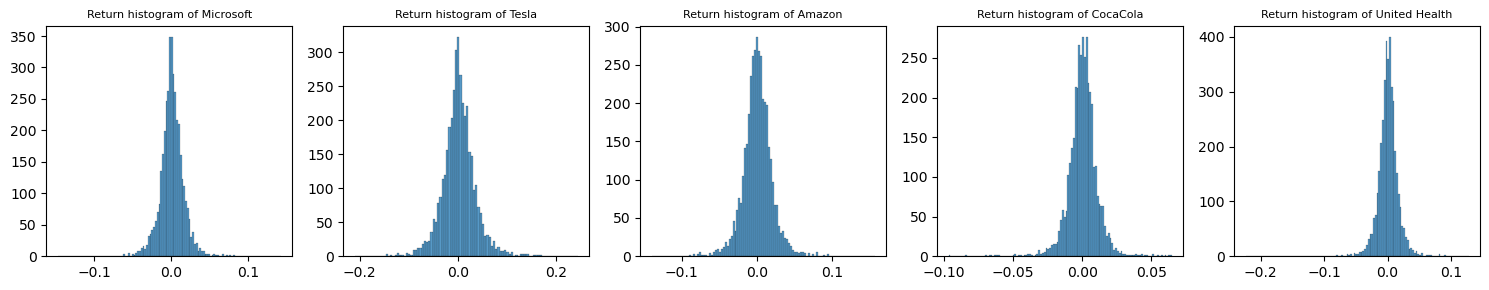

In [11]:
# Figure 1: Histogram subplots for each asset return
asset_ret_hist = asset_return_histogram(asset_return_df)

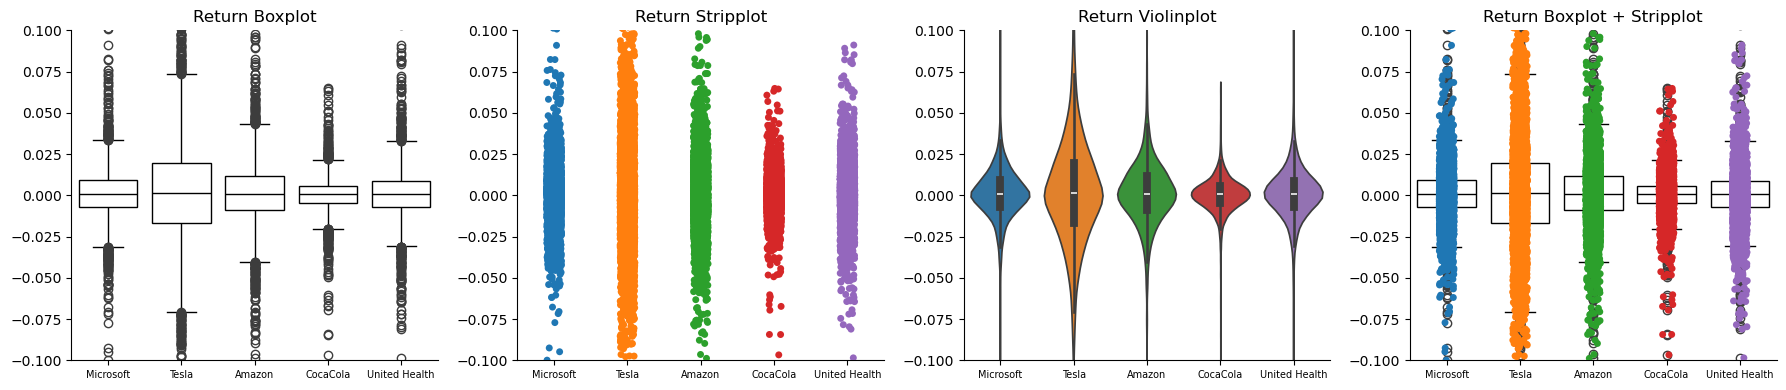

In [12]:
# Figure 2: Boxplot, Stripplot, Violinplot, and Overlaid Boxplot+Stripplot
asset_plots = asset_return_plots(asset_return_df)

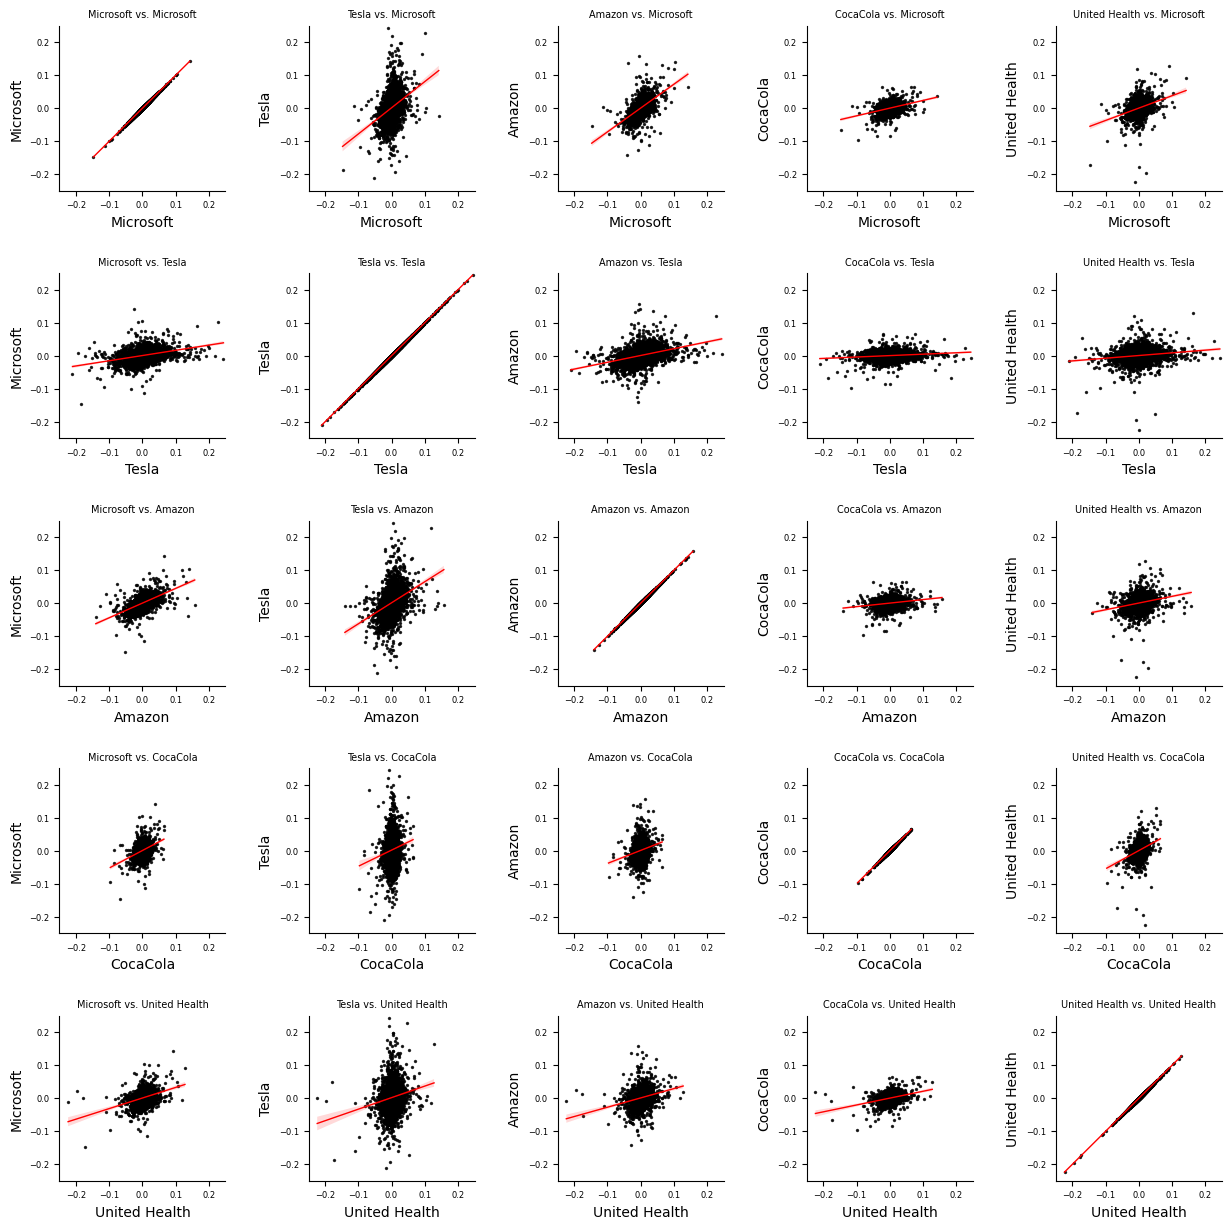

In [13]:
# Figure 3: Full 5x5 grid of bivariate regplots
asset_ret_regplots = asset_return_regplots(asset_return_df)